In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Function Definitions Required to Calculate FF

In [2]:
def degree(G,W):
    nodes = list(G.nodes())
    w_degree = []
    for i in range(0, len(nodes)):
        deg = []
        nd = nodes[i]
        m_dg = modi_deg(G,nd,W)
        deg.append(nd)
        deg.append(m_dg)
        w_degree.append(deg)
    return w_degree

# New One
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)

    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]

    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)

    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})

        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val

        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        v = edge_weighted(G,nd)
        closeness.append(nd)
        closeness.append(weight)
        closeness.append(v)
        w_closeness.append(closeness)
    return w_closeness
# End of New One

# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def ThetaVal(G):
    nodes = list(G.nodes())
    val = []
    for i in range(0, len(nodes)):
        ap = []
        nd = nodes[i]
        v = edge_weighted(G,nd)
        ap.append(nd)
        ap.append(v)
        val.append(ap)
    return val

def calculateFF(G, edge):
    i_n = edge[0]
    j_n = edge[1]
    d_i = G.degree(i_n, weight='weight')
    d_j = G.degree(j_n, weight='weight')
    t_i = edge_weighted(G,i_n)
    t_j = edge_weighted(G,j_n)
    W = total_weight_of_G(G)
    e_w = G.get_edge_data(i_n, j_n)
    w_ij = e_w['weight']
    val = (((d_i + t_i) / W) + ((d_j + t_j) / W)) * (w_ij / W)
    return val

Function to Calculation FF

In [3]:
def FamiliarityFactor(G):
    eg = G.edges()
    edges = list(eg)
    ff_edges = []
    for i in range(0, len(edges)):
        f_e = []
        ed = edges[i]
        f = calculateFF(G, ed)
        f_e.append(ed)
        f_e.append(f)
        ff_edges.append(f_e)
    ret = dict(ff_edges)
    return ret

Input graph

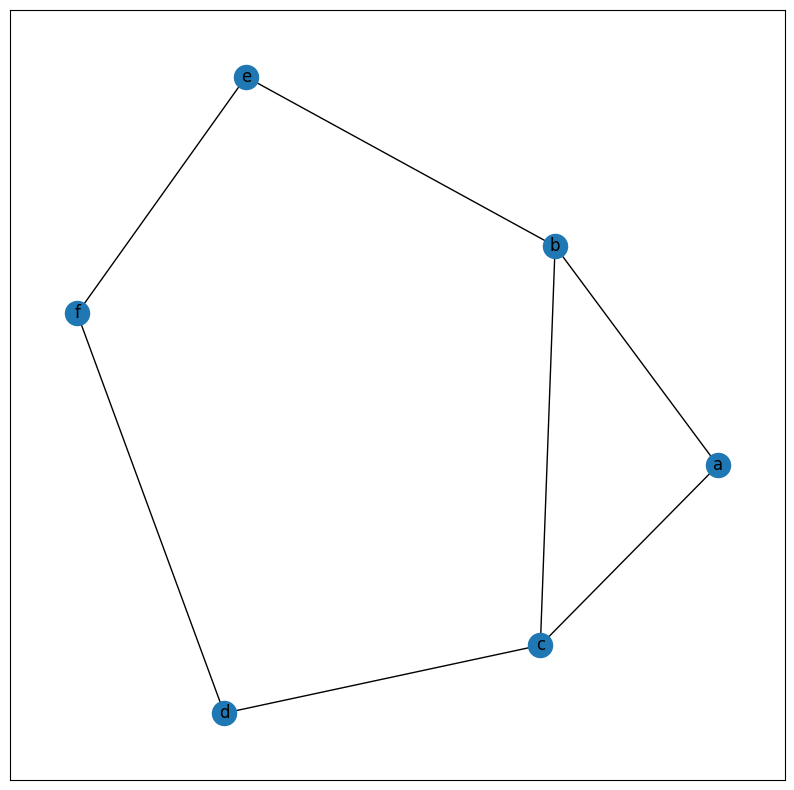

In [4]:
ss_1 = nx.read_weighted_edgelist('ex.txt', delimiter=',')
#print(nx.info(ss_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(ss_1)
plt.show()

Calculate FF

In [5]:
res = FamiliarityFactor(ss_1)

Print the Result

In [6]:
res

{('a', 'b'): 0.32000000000000006,
 ('a', 'c'): 0.30000000000000004,
 ('b', 'c'): 0.17000000000000004,
 ('b', 'e'): 0.16000000000000003,
 ('c', 'd'): 0.15000000000000002,
 ('e', 'f'): 0.24,
 ('d', 'f'): 0.12}